# Convergence: can you trust these numbers?

Every figure of merit the eigenmode solver reports is computed on a mesh, so before you
quote one it is worth checking that it has stopped changing as the mesh is refined. A
value that has settled is one you can rely on; a value still moving is telling you the
mesh, not the cavity.

This notebook runs one cavity over a grid of mesh settings and shows, for every figure of
merit, what happens to the number as the mesh is refined — the accelerating (monopole)
quantities and the deflecting (dipole) ones alike. It ends with the settings to use, and
with the quantities on this cavity that need more care than the rest.

The two knobs are the element size `h` and the polynomial order `p`, both set through
`eigenmode_config['mesh_config']`.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style, WARM

set_verbose(False)
apply_style()
WORK = tempfile.mkdtemp()

## 1. The cavity and the sweep

A two-cell TESLA cavity with beam pipes at both ends — two cells so the cell-to-cell
coupling `kcc` and the field flatness `ff` exist, and with the real (unequal) TESLA end
cells so `ff` is not trivially 100 %.

Each mesh is solved for both polarisations, and the figures of merit are read off the
accelerating $\pi$-mode and the lowest deflecting mode.

Note how the element sizes are chosen: each polynomial order gets its own list, with the
lower orders taken to much finer meshes. A low order needs a far finer mesh before its
answer settles, so sweeping every order over the same element sizes would cut the low-order
curves off while they are still moving — and make a quantity that does converge look as
though it never does.

In [2]:
MID = [42, 42, 12, 19, 35, 57.7, 103.353]              # A, B, a, b, Ri, L, Req  [mm]
END_L = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
END_R = [42, 42, 9, 12.8, 39, 56.815, 103.353]

LONGITUDINAL = ['freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
                'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]', 'kcc [%]', 'ff [%]']
TRANSVERSE = ['freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
              'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]']
ALL_QOIS = LONGITUDINAL + [q for q in TRANSVERSE if q not in LONGITUDINAL]

# Each order gets its own element sizes. A low order needs a much finer mesh
# before it settles, so a single shared list of h would stop the p = 2 curve
# while it is still moving and make it look as though it never converges.
# These are chosen so every order spans a comparable number of degrees of freedom.
H_FOR_P = {2: [24, 16, 11, 7.5, 5, 3.5],
           3: [24, 16, 11, 7.5, 5],
           4: [24, 16, 11, 7.5],
           5: [24, 16, 11]}
REF_H, REF_P = 6, 6                 # the fine solve everything is compared against


def solve(h, p, n_modes=6):
    '''Solve both polarisations at (h, p).'''
    cav = EllipticalCavity(2, MID, END_L, END_R, beampipe='both', name=f'h{h}p{p}')
    cav.set_workspace(os.path.join(WORK, f'h{h}_p{p}'))
    cav.eigenmode.run({'polarisation': ['monopole', 'dipole'], 'n_modes': n_modes,
                       'boundary_conditions': 'mm', 'processes': 1,
                       'mesh_config': {'h': h, 'p': p}})
    ndof = {pol: cav.eigenmode.mpole_qois(pol, all_modes=False)['No of DOFs']
            for pol in ('monopole', 'dipole')}
    return cav.eigenmode.qois_df, ndof


def pick(df, m, f_ref):
    '''The mode of azimuthal number m closest in frequency to the reference mode.
    Matching by frequency rather than by index keeps the same physical mode on
    every mesh, which a mode index does not.'''
    g = df[df['m'] == m]
    return g.loc[(g['freq [MHz]'] - f_ref).abs().idxmin()]

In [3]:
ref_df, ref_ndof = solve(REF_H, REF_P)
band = ref_df[ref_df['m'] == 0].nsmallest(2, 'freq [MHz]')   # fundamental passband
ref_mono = band.loc[band['R/Q [Ohm]'].idxmax()]              # its pi-mode
ref_dip = ref_df[ref_df['m'] == 1].nsmallest(1, 'freq [MHz]').iloc[0]
ref = {'monopole': {k: float(ref_mono[k]) for k in ALL_QOIS},
       'dipole': {k: float(ref_dip[k]) for k in ALL_QOIS}}

records = {'monopole': [], 'dipole': []}
for p, hs in H_FOR_P.items():
    for h in hs:
        df, ndof = solve(h, p)
        for pol, m in (('monopole', 0), ('dipole', 1)):
            q = pick(df, m, ref[pol]['freq [MHz]'])
            records[pol].append({'h': h, 'p': p, 'ndof': ndof[pol],
                                 **{k: float(q[k]) for k in ALL_QOIS}})
        print(f'h = {h:4.1f} mm, p = {p}   {ndof["monopole"]:6d} DOFs', flush=True)

mono = pd.DataFrame(records['monopole'])
dip = pd.DataFrame(records['dipole'])
pd.DataFrame(ref).round(4)

h = 24.0 mm, p = 2     1791 DOFs


h = 16.0 mm, p = 2     2640 DOFs


h = 11.0 mm, p = 2     4404 DOFs


h =  7.5 mm, p = 2     8358 DOFs


h =  5.0 mm, p = 2    19146 DOFs


...

h =  7.5 mm, p = 4    24760 DOFs


h = 24.0 mm, p = 5     7632 DOFs


h = 16.0 mm, p = 5    11310 DOFs


h = 11.0 mm, p = 5    18960 DOFs


,monopole,dipole
freq [MHz],1300.0857,1642.4324
R/Q [Ohm],218.8807,10.8883
G [Ohm],272.5210,240.1044
Epk/Eacc [],2.0224,15.3296
Bpk/Eacc [mT/MV/m],4.2562,116.7419
kcc [%],0.9491,0.0000
ff [%],99.8358,39.3375


## 2. The values, as the mesh is refined

The direct evidence: each figure of merit plotted as its own value against the size of the
solve, one line per polynomial order. A curve that flattens has settled — refining further
does not change the answer, so the answer is the cavity's and not the mesh's. The dashed
line marks the fine solve.

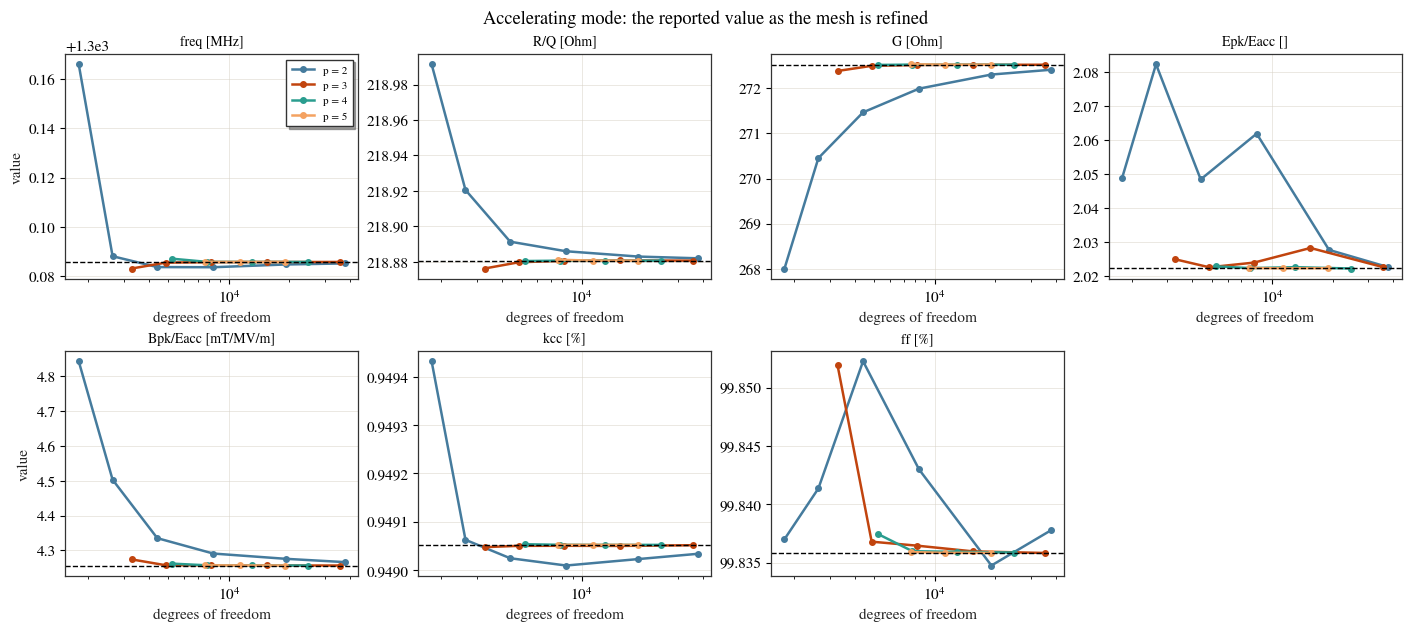

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='degrees of freedom'>,
        <Axes: >]], dtype=object)

In [4]:
def plot_values(frame, ref_row, qois, title):
    '''Each QOI's actual value against the size of the solve, one line per order.'''
    ncols = 4
    nrows = int(np.ceil(len(qois) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.1 * nrows),
                             squeeze=False, layout='constrained')
    for ax, q in zip(axes.ravel(), qois):
        for i, (p, g) in enumerate(frame.groupby('p')):
            g = g.sort_values('ndof')
            ax.plot(g['ndof'], g[q], 'o-', ms=4, color=WARM[i % len(WARM)],
                    label=f'p = {p}')
        ax.axhline(ref_row[q], ls='--', color='k', lw=1)
        ax.set_xscale('log')
        ax.set_title(q, fontsize=10)
        ax.set_xlabel('degrees of freedom')
    for row in axes:
        row[0].set_ylabel('value')
    axes[0, 0].legend(fontsize=8)
    for ax in axes.ravel()[len(qois):]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()
    return axes


plot_values(mono, ref['monopole'], LONGITUDINAL,
            'Accelerating mode: the reported value as the mesh is refined')

Read each panel left to right: as the solve grows, does the curve flatten onto the dashed
line?

It does, for every quantity and every order. `p = 4` and `p = 5` lie on the line from their
coarsest mesh onwards: those orders are converged everywhere in this grid. `p = 2` and
`p = 3` start away from it and take their whole h list to arrive, which is the point of
giving each order its own. `Epk/Eacc` at `p = 2` wanders between 2.05 and 2.08 for four
meshes before dropping onto the line, and at `p = 3` it climbs away from the line before
coming back.

`ff` converges like the rest. Every mesh in the grid lands within 0.02 of a percentage point
of the fine solve, and `p = 5` within $10^{-6}$ of it on every mesh.

That agreement is the result worth taking away. Independent discretisations, using
different element sizes and different polynomial orders, land on the same number. A value
reproduced that way by independent means is one you can quote.

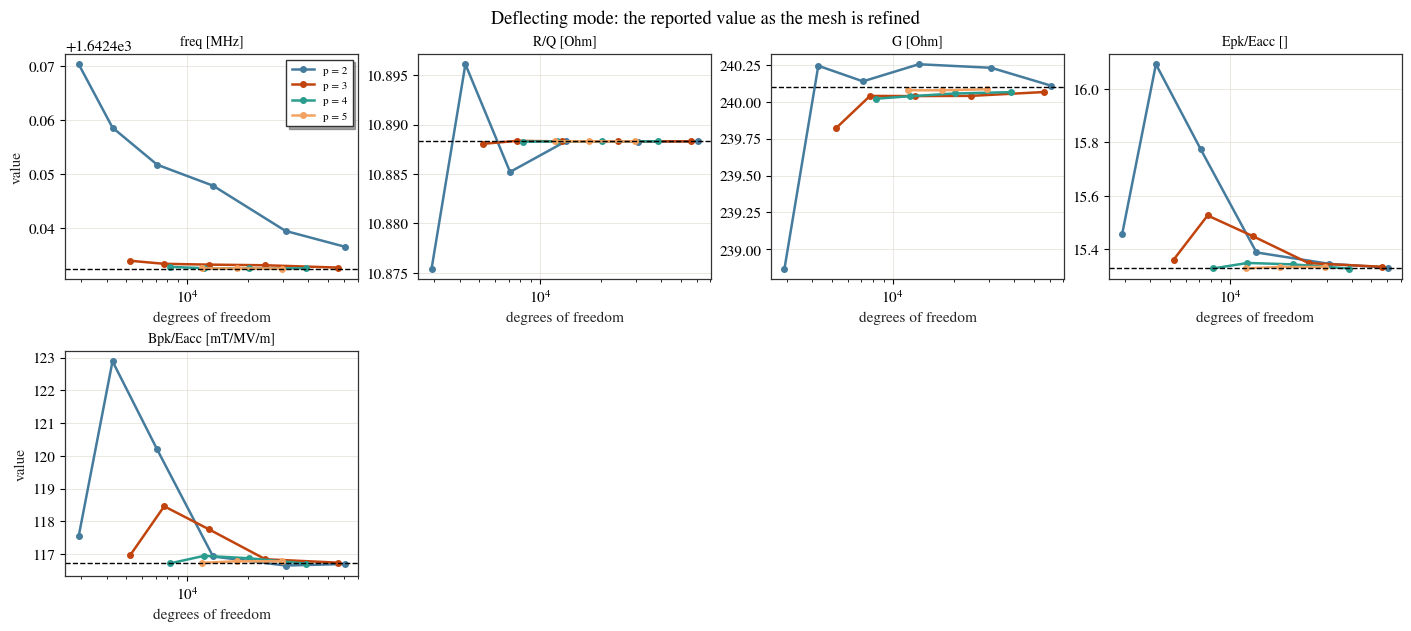

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [5]:
plot_values(dip, ref['dipole'], TRANSVERSE,
            'Deflecting mode: the reported value as the mesh is refined')

The deflecting mode converges too, more slowly and less tidily. Its frequency at `p = 2`
approaches the line from above across the whole h list without reaching it; `p = 3` and
above are on it. Its transverse `R/Q` settles for every order after a wobble at `p = 2`, and
so does `G`, which is within 0.1 % from the second mesh of every order.

The peak-field ratios are the slowest here: at `p = 2` and `p = 3` they zig-zag around the
line and are still moving at the finest mesh in this grid. Use `p = 5` for the deflecting
peak fields. Section 4 shows where the zig-zag comes from.

## 3. How close is settled?

The same data as a relative difference from the fine solve, which puts a number on it.
The dotted line is 0.1 %.

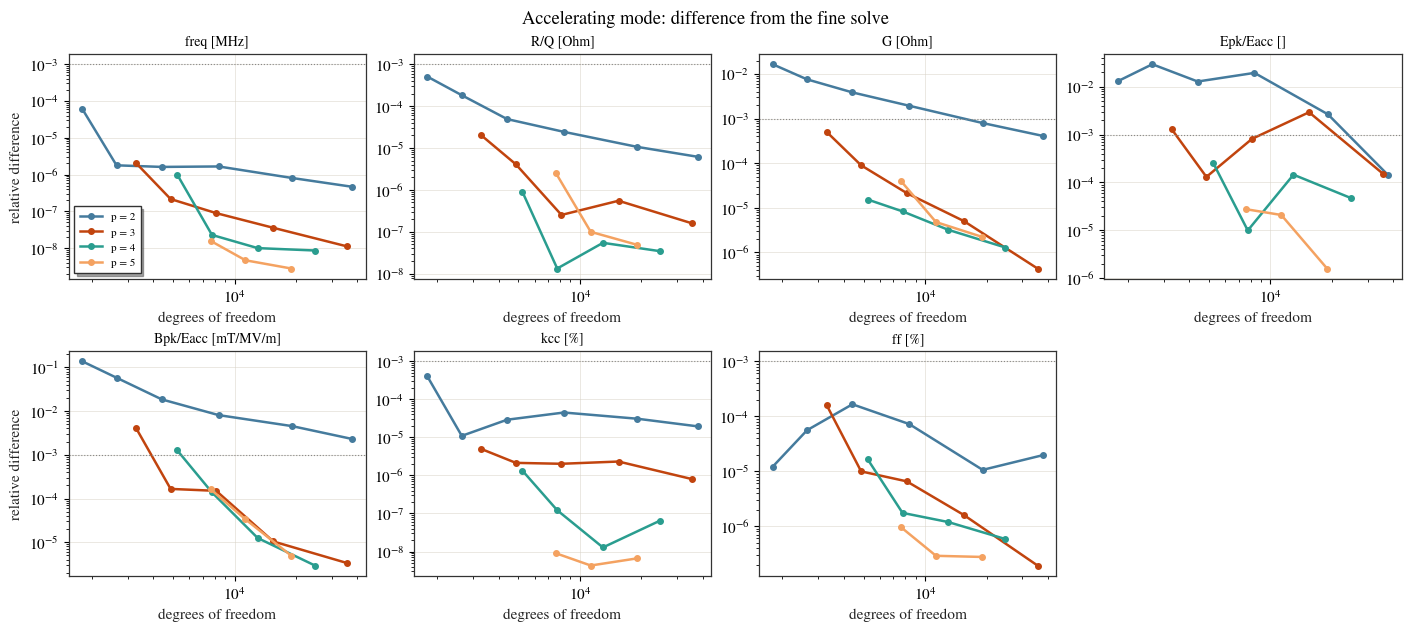

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='degrees of freedom'>,
        <Axes: >]], dtype=object)

In [6]:
def error_frame(frame, ref_row, qois):
    out = frame[['h', 'p', 'ndof']].copy()
    for q in qois:
        r = float(ref_row[q])
        out[q] = np.abs(frame[q] - r) / (abs(r) if abs(r) > 1e-12 else 1.0)
    return out


def plot_errors(err, qois, title):
    ncols = 4
    nrows = int(np.ceil(len(qois) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.1 * nrows),
                             squeeze=False, layout='constrained')
    for ax, q in zip(axes.ravel(), qois):
        for i, (p, g) in enumerate(err.groupby('p')):
            g = g.sort_values('ndof')
            ax.plot(g['ndof'], g[q].replace(0, np.nan), 'o-', ms=4,
                    color=WARM[i % len(WARM)], label=f'p = {p}')
        ax.axhline(1e-3, color='#888888', lw=0.8, ls=':')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(q, fontsize=10)
        ax.set_xlabel('degrees of freedom')
    for row in axes:
        row[0].set_ylabel('relative difference')
    axes[0, 0].legend(fontsize=8)
    for ax in axes.ravel()[len(qois):]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()
    return axes


err_mono = error_frame(mono, ref['monopole'], LONGITUDINAL)
err_dip = error_frame(dip, ref['dipole'], TRANSVERSE)
plot_errors(err_mono, LONGITUDINAL, 'Accelerating mode: difference from the fine solve')

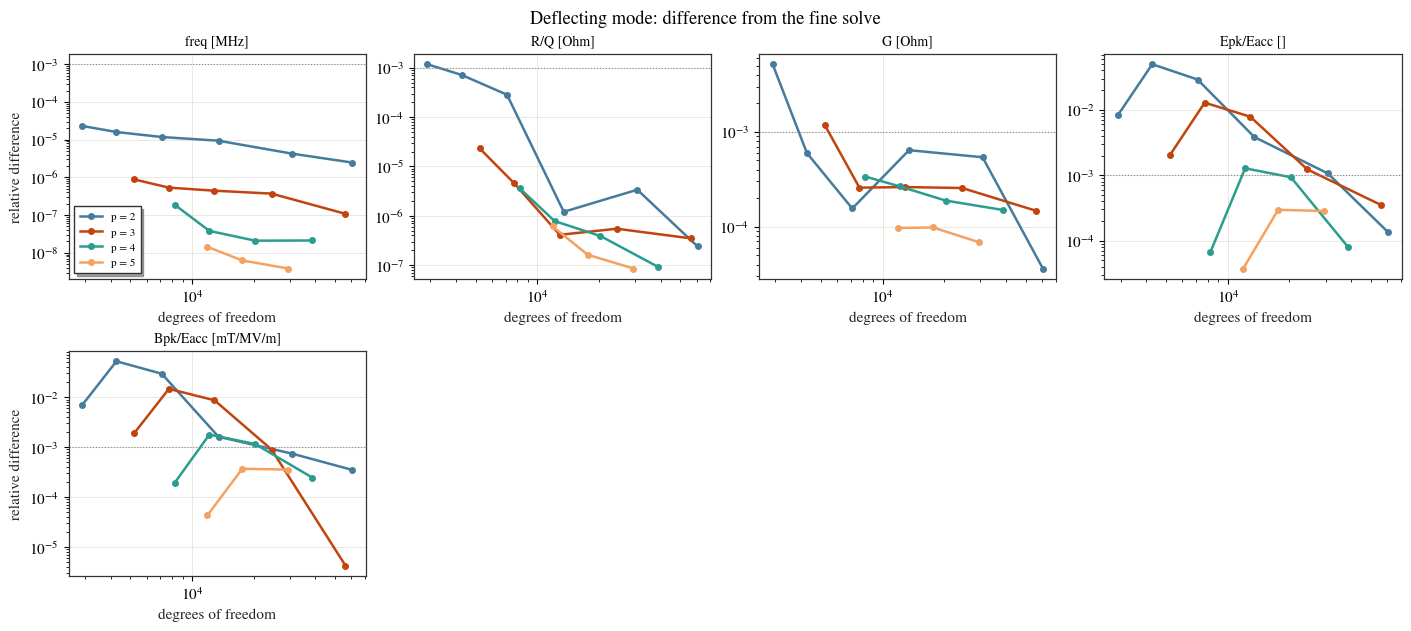

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [7]:
plot_errors(err_dip, TRANSVERSE, 'Deflecting mode: difference from the fine solve')

## 4. Why some curves zig-zag

The frequency panels fall steadily; several of the others do not. That difference has a
cause worth knowing before reading any convergence plot.

The frequency is special: a refined mesh can only lower the computed eigenvalue towards the
true one, so its error keeps one sign and shrinks. R/Q, G and the peak fields have no such
guarantee, and their error can change sign between meshes. On a log plot of the size of the
error, a change of sign shows up as a sharp dip that is not an improvement.

The second cause is the sweep itself. Every element size above is a new, unrelated mesh, and
each mesh has its own error for pointwise and surface quantities. Refining one mesh
uniformly instead, so that every level subdivides the one before, removes that variation.
`study_mesh_convergence(theta=0)` does exactly that. Below, the 24 mm mesh and its uniform
subdivisions, against the independent meshes of section 1, for the three slowest
quantities. A filled marker is a value above the fine solve, a hollow one below it.

In [8]:
def nested(p, levels):
    '''The 24 mm mesh and `levels` uniform subdivisions of it, at order p.'''
    cav = EllipticalCavity(2, MID, END_L, END_R, beampipe='both', name=f'nested_p{p}')
    cav.set_workspace(os.path.join(WORK, f'nested_p{p}'))
    cav.study_mesh_convergence(h=24, p=p, p_passes=1, n_modes=6, theta=0,
                               polarisation=('monopole', 'dipole'),
                               max_refinements=levels, max_ndof=10**7,
                               eigenmode_config={'boundary_conditions': 'mm'})
    df = cav.convergence_df_data
    out = {'monopole': [], 'dipole': []}
    for level, g in df.groupby('h_pass'):
        for pol, m in (('monopole', 0), ('dipole', 1)):
            q = pick(g, m, ref[pol]['freq [MHz]'])
            out[pol].append({'level': level, 'ndof': int(q['No of DOFs']),
                             **{k: float(q[k]) for k in ALL_QOIS}})
    return {pol: pd.DataFrame(rows) for pol, rows in out.items()}


nested_runs = {3: nested(3, 3), 4: nested(4, 2)}

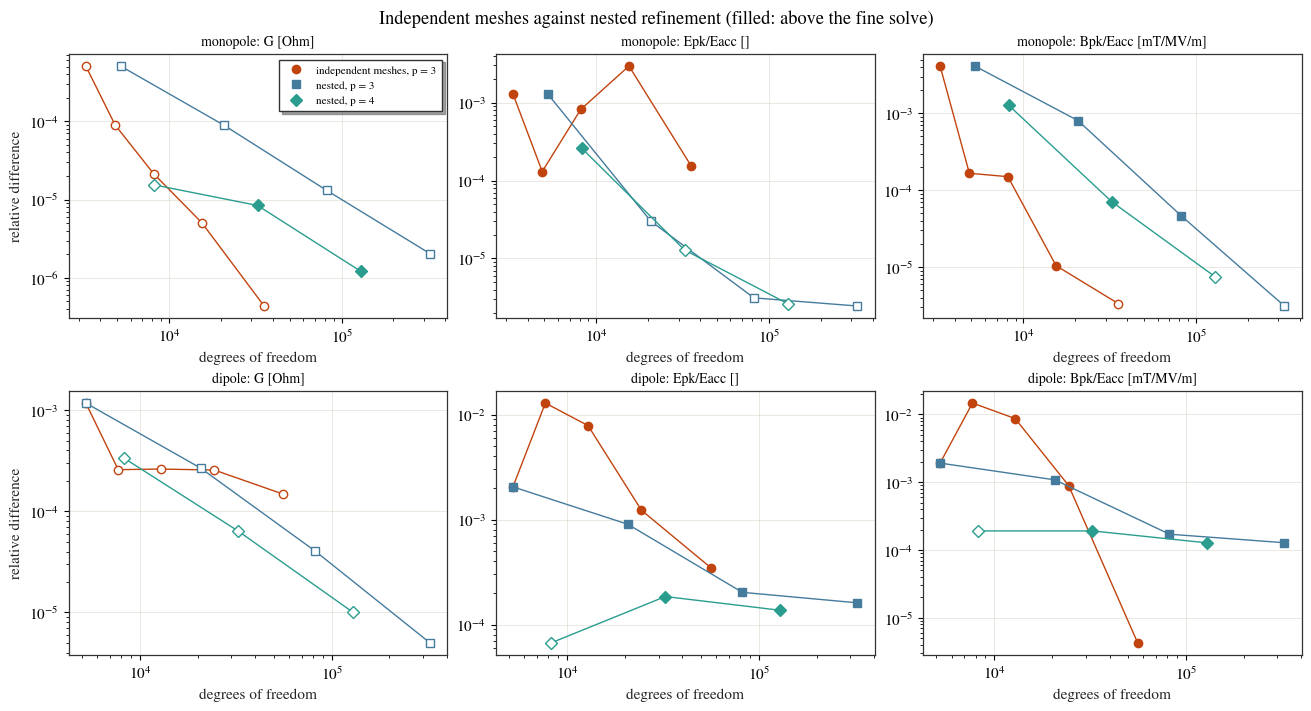

In [9]:
SLOW = ['G [Ohm]', 'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]']


def plot_signed(ax, frame, ref_row, q, color, marker, label):
    '''|error| on log axes, filled where the value is above the reference, hollow below.'''
    f = frame.sort_values('ndof')
    e = f[q] / ref_row[q] - 1
    ax.plot(f['ndof'], e.abs(), '-', color=color, lw=1)
    above = e > 0
    ax.plot(f['ndof'][above], e.abs()[above], marker, color=color, ms=6, label=label)
    ax.plot(f['ndof'][~above], e.abs()[~above], marker, color=color, ms=6, mfc='white')


fig, axes = plt.subplots(2, 3, figsize=(13, 7), layout='constrained')
for row, (pol, frame) in zip(axes, (('monopole', mono), ('dipole', dip))):
    for ax, q in zip(row, SLOW):
        plot_signed(ax, frame[frame['p'] == 3], ref[pol], q, WARM[1], 'o',
                    'independent meshes, p = 3')
        plot_signed(ax, nested_runs[3][pol], ref[pol], q, WARM[0], 's', 'nested, p = 3')
        plot_signed(ax, nested_runs[4][pol], ref[pol], q, WARM[2], 'D', 'nested, p = 4')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{pol}: {q}', fontsize=10)
        ax.set_xlabel('degrees of freedom')
    row[0].set_ylabel('relative difference')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Independent meshes against nested refinement (filled: above the fine solve)')
plt.show()

The nested sequences fall steadily; the zig-zags belong to the independent meshes. On one
mesh and its subdivisions the monopole `Epk/Eacc` at `p = 3` goes from $1.3\times10^{-3}$ to
$3\times10^{-5}$ to $3\times10^{-6}$, while independent meshes of comparable size scatter
between $1.3\times10^{-4}$ and $3\times10^{-3}$. `G` converges steadily either way: it is an
integral over the wall, which averages out what a single point cannot.

A peak field zig-zags on independent meshes because it is a single point of a field whose
magnitude jumps slightly from one element to the next (only its tangential part is
continuous). A new mesh moves those jumps relative to the peak. The effect shrinks as the
mesh is refined, but not steadily.

The dipole panels show one more thing. Both nested sequences, at `p = 3` and `p = 4`, level
off at the same value, $1.4\times10^{-4}$ above the fine solve for `Epk/Eacc` and
`Bpk/Eacc`. That is the fine solve's own error in those two quantities: below that level the
curves in section 3 measure the reference rather than the mesh.

## 5. Which mesh do you need?

For each figure of merit, the cheapest solve in the grid that comes within 0.1 % of the
fine one *and stays there on every finer mesh*. The second condition matters: a quantity
that is still moving can pass through the right answer on a coarse mesh and leave again, and
a mesh chosen on one lucky agreement is not a mesh you can trust. A blank row means nothing
in this grid qualified.

In [10]:
def cheapest_within(err, qois, tol=1e-3):
    rows = {}
    for q in qois:
        best = None
        for _, r in err.sort_values('ndof').iterrows():
            finer = err[(err['p'] == r['p']) & (err['h'] <= r['h'])]
            if (finer[q] <= tol).all():
                best = r
                break
        rows[q] = ({'h [mm]': int(best['h']), 'p': int(best['p']),
                    'DOFs': int(best['ndof'])} if best is not None else
                   {'h [mm]': None, 'p': None, 'DOFs': None})
    return pd.DataFrame(rows).T


pd.concat({'monopole': cheapest_within(err_mono, LONGITUDINAL),
           'dipole': cheapest_within(err_dip, TRANSVERSE)})

h [mm]  p   DOFs
monopole freq [MHz]              24  2   1791
         R/Q [Ohm]               24  2   1791
         G [Ohm]                 24  3   3288
         Epk/Eacc []             24  4   5235
         Bpk/Eacc [mT/MV/m]      16  3   4860
         kcc [%]                 24  2   1791
         ff [%]                  24  2   1791
dipole   freq [MHz]              24  2   2908
         R/Q [Ohm]               16  2   4276
         G [Ohm]                 16  2   4276
         Epk/Eacc []             24  5  11890
         Bpk/Eacc [mT/MV/m]      24  5  11890

## 6. What to use, and what to watch

For this cavity:

- `p = 4` settles every accelerating-mode quantity, `ff` included, to about $10^{-4}$ from
  `h = 16` mm down; at 24 mm only `Bpk/Eacc` is still 0.13 % off. `p = 5` settles the
  deflecting-mode peak fields too. Those are the settings to reach for.
- A lower order is not wrong, it is slower: `p = 2` reaches the same answers, but only on a
  much finer mesh. At the defaults, `h = 20` mm and `p = 3`, the accelerating mode's
  frequency, R/Q, G, kcc and ff are within 0.1 %; its peak fields need `p = 4`.
- `Epk/Eacc` and `Bpk/Eacc` are the slowest to arrive, and on independent meshes they move
  around rather than steadily towards the answer (section 4). Two meshes that happen to
  agree are not evidence of convergence for these: look for a run of meshes that agree, or
  refine one mesh uniformly with `study_mesh_convergence(theta=0)`.
- `ff` converges like everything else. At `p = 4` it agrees with the fine solve to a few
  parts in $10^6$.
- Higher orders are safe. On this cavity `p = 7` and `p = 8` still improve the frequency and
  agree with the fine solve on every figure of merit, to $10^{-6}$ or better for the
  accelerating mode. Past `p = 5` the figures of merit are limited by how precisely one mesh
  resolves a peak field, not by the order.
- A single fine solve is a reference with errors of its own in pointwise quantities: about
  $10^{-4}$ for this cavity's deflecting peak fields. Differences below that measure the
  reference.

Section 5's table uses a 0.1 % tolerance, which is looser than the eye applies in section 2:
use the table to size a solve for a stated tolerance, and the plots to decide what "settled"
means for your purpose.

A reasonable default covering the accelerating-mode figures of merit:

```python
cav.eigenmode.run({'mesh_config': {'h': 16, 'p': 4}, ...})
```

and `p = 5` if you need the deflecting-mode peak fields too.

Three things to carry to a cavity of your own, because they are not specific to this one:

- Check convergence for the quantity you are going to report, not just the frequency.
- Refine each order far enough. A low order needs a much finer mesh than a high one, so a
  sweep that uses the same element sizes for every order will cut the low orders off
  mid-flight and make a converging quantity look divergent.
- A quantity whose value moves non-monotonically has not converged yet, even if two
  neighbouring meshes agree.

A cavity with a sharp corner in its wall is the one case where a peak field will never
settle, at any mesh: the field is genuinely unbounded at a re-entrant corner, so
`Epk/Eacc` there keeps climbing with refinement rather than converging. Smooth walls, like
this cavity's, are fine.

See also [Mesh convergence: how fine is fine enough?](mesh_convergence.ipynb), which checks
the fundamental frequency against a closed-form answer, and
[Solver settings: time against accuracy](solver_settings.ipynb), which holds the mesh fixed
and measures what the eigensolver's own settings cost and buy.